# UC1 -- Seasonal Baseline V1 vs V2

**Goal.** Decide whether to switch the seasonal-baseline detector from the
current rolling-window MAD scheme (V1) to the hourly-summary buffer scheme
(V2). Both are evaluated head-to-head on NASA HTTP 1995 and on synthetic
data with injected ground-truth spikes.

**The two detectors:**

|                          | V1 (current)                                   | V2 (proposed)                                   |
|--------------------------|------------------------------------------------|-------------------------------------------------|
| Storage                  | 21 days of per-minute values                   | 24 * 21 = 504 (median, IQR) pairs               |
| Per-series memory        | ~30k floats (~240 KB)                          | ~1k floats (~8 KB)                              |
| Per-minute scoring cost  | recompute median+MAD over ~900-1260 vals       | combine 3-15 pre-computed pairs                 |
| Robustness               | median + MAD over raw minutes                  | median-of-medians + median-of-IQRs              |
| Bucketing                | (hour, is_weekend) -- 48 buckets               | (hour, pool_key) at inference time              |

**Calibration discipline.** Each detector's threshold k is calibrated
against benign minutes anywhere in the series (not just the test region)
to a fixed FPR target (default 0.5%). This matches the standalone V1/V2
notebooks and the ensemble notebook -- one calibration recipe, applied
identically across all four notebooks. We report "F1 at fixed FPR" and
"event coverage at fixed FPR" rather than "best F1 over a sweep" (which
overfits the threshold to the test labels).

**What the verdict depends on.** At the same calibrated FPR, does V2
produce comparable event coverage and recall? If yes, switch (V2 wins on
memory and CPU with no cost). If V2's recall drops by more than ~5
points relative to V1, the trade-off needs to be considered.

**Synthetic limitation note.** The synthetic generator below produces
iid Poisson noise around a smooth diurnal+weekly mean. Real web traffic
has positive serial correlation at short lags. This makes the EMA /
Z-Score detectors look better than they should on synthetic, and is
mildly unfair to the seasonal detector. NASA results are more reflective
of real deployment behavior; use synthetic only to control for
ground-truth label uncertainty.


In [53]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# ---- Config ----------------------------------------------------------
WINDOW_DAYS    = 21       # rolling history for both detectors
TARGET_FPR     = 0.005    # threshold calibration target (per-minute FPR)
SCALE_FLOOR    = 1.0      # V2 IQR floor; prevents division by near-zero
EPS            = 1e-6
MIN_SAMPLES_V1 = 15       # V1 needs n >= 15 same-bucket raw minutes to score
MIN_SAMPLES_V2 = 2        # V2 needs n >= 2 same-(hour, pool) hourly summaries.
                          # 2 hourly summaries already encode 2 * 60 = 120
                          # underlying minute observations, so V2 is more
                          # conservative on coverage than V1's 15-minute floor.

# Paths
LOG_FILE = Path("./data/nasa.csv")
OUT_DIR  = Path("./outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TS_COL      = "time"
TS_IS_EPOCH = True

pd.set_option("display.max_columns", 50)
np.random.seed(42)


## 1. Detector implementations

Both detectors return a robust_z series; the binary flag is applied later
with a per-detector calibrated k. Identical input contract: a DataFrame
with timestamp and value (per-minute request count).

### 1.1 V1 -- rolling per-minute MAD

For each minute t, compute median + MAD over same-(hour, is_weekend) raw
minute-values in the preceding 21 days. Robust z = (x - median) /
(1.4826 * MAD + eps).


In [54]:
def detector_v1(df, window_days=WINDOW_DAYS, min_samples=MIN_SAMPLES_V1):
    """V1: rolling 21-day window of raw per-minute values, median+MAD per (hour, is_weekend)."""
    df = df.sort_values("timestamp").reset_index(drop=True).copy()
    df["hour"]       = df["timestamp"].dt.hour.astype(np.int8)
    df["is_weekend"] = (df["timestamp"].dt.dayofweek >= 5).astype(np.int8)
    df["bucket"]     = df["hour"].astype(np.int16) * 2 + df["is_weekend"]

    window = pd.Timedelta(days=window_days)
    med_out = np.full(len(df), np.nan)
    mad_out = np.full(len(df), np.nan)

    for _, grp in df.groupby("bucket", sort=False):
        idx  = grp.index.to_numpy()
        ts   = grp["timestamp"].to_numpy()
        vals = grp["value"].to_numpy(dtype=np.float64)
        left = 0
        for right in range(len(grp)):
            t_left_bound = ts[right] - window
            while ts[left] < t_left_bound:
                left += 1
            window_vals = vals[left:right]    # strictly before current point
            if len(window_vals) >= min_samples:
                med = np.median(window_vals)
                med_out[idx[right]] = med
                mad_out[idx[right]] = np.median(np.abs(window_vals - med))

    df["baseline_v1"] = med_out
    df["scale_v1"]    = mad_out
    df["robust_z_v1"] = (df["value"] - df["baseline_v1"]) / (
        1.4826 * df["scale_v1"] + EPS
    )
    return df[["timestamp", "value", "baseline_v1", "scale_v1", "robust_z_v1"]]


### 1.2 V2 -- hourly summary buffer

Two stages. **Build phase**: at every hour boundary, compute median and IQR
of that hour's 60 minute-values; write (date, hour, median, IQR) to a
rolling buffer. **Score phase**: at minute t with hour=h and pool_key=p,
look up same-(hour=h, pool_key=p) entries from the buffer in the past N
days, take median-of-medians for the baseline and median-of-IQRs for the
scale. Robust z = (x - baseline) / (0.7413 * scale_floored + eps).

Two pooling variants implemented:
- V2-weekend: pool by is_weekend (n ~ 15 entries -- matches V1's bucketing)
- V2-dow: pool by exact day-of-week (n ~ 3 entries -- alternative bucketing)

Running both lets us isolate the storage scheme effect from the
bucketing effect.


In [55]:
def detector_v2(df, window_days=WINDOW_DAYS, pooling="is_weekend",
                min_samples=MIN_SAMPLES_V2, scale_floor=SCALE_FLOOR):
    """V2: hourly (median, IQR) buffer; median-of-N over same-(hour, pool_key) entries."""
    df = df.sort_values("timestamp").reset_index(drop=True).copy()

    # Build phase: per-minute -> per-hour summaries.
    def _iqr(x):
        return float(np.subtract(*np.percentile(x, [75, 25]))) if len(x) >= 4 else np.nan

    hourly = (df[["timestamp", "value"]]
                .resample("1h", on="timestamp")
                .agg(h_median=("value", "median"),
                     h_iqr=("value", _iqr))
                .reset_index()
                .rename(columns={"timestamp": "ts_hour"}))
    hourly["hour"]       = hourly["ts_hour"].dt.hour.astype(np.int8)
    hourly["dow"]        = hourly["ts_hour"].dt.dayofweek.astype(np.int8)
    hourly["is_weekend"] = (hourly["dow"] >= 5).astype(np.int8)

    window = pd.Timedelta(days=window_days)
    n_hours = len(hourly)
    baseline = np.full(n_hours, np.nan)
    scale    = np.full(n_hours, np.nan)
    n_used   = np.zeros(n_hours, dtype=np.int16)

    pool_col = pooling
    ts_arr   = hourly["ts_hour"].to_numpy()
    hour_arr = hourly["hour"].to_numpy()
    pool_arr = hourly[pool_col].to_numpy()
    med_arr  = hourly["h_median"].to_numpy()
    iqr_arr  = hourly["h_iqr"].to_numpy()

    for i in range(n_hours):
        match = (
            (hour_arr == hour_arr[i]) &
            (pool_arr == pool_arr[i]) &
            (ts_arr   <  ts_arr[i])   &
            (ts_arr   >= ts_arr[i] - window)
        )
        if match.sum() >= min_samples:
            cand_med = med_arr[match]; cand_med = cand_med[~np.isnan(cand_med)]
            cand_iqr = iqr_arr[match]; cand_iqr = cand_iqr[~np.isnan(cand_iqr)]
            if len(cand_med) >= min_samples and len(cand_iqr) >= min_samples:
                baseline[i] = np.median(cand_med)
                scale[i]    = np.median(cand_iqr)
                n_used[i]   = len(cand_med)

    hourly["baseline"] = baseline
    hourly["scale"]    = scale
    hourly["n_used"]   = n_used

    df["ts_hour"] = df["timestamp"].dt.floor("1h")
    out = df.merge(hourly[["ts_hour", "baseline", "scale", "n_used"]],
                   on="ts_hour", how="left")

    out["scale_floored"] = out["scale"].clip(lower=scale_floor)
    out[f"robust_z_v2_{pooling}"] = (
        (out["value"] - out["baseline"]) /
        (0.7413 * out["scale_floored"] + EPS)
    )
    out = out.rename(columns={
        "baseline": f"baseline_v2_{pooling}",
        "scale":    f"scale_v2_{pooling}",
        "n_used":   f"n_used_v2_{pooling}",
    })
    keep = ["timestamp", "value",
            f"baseline_v2_{pooling}", f"scale_v2_{pooling}",
            f"n_used_v2_{pooling}",  f"robust_z_v2_{pooling}"]
    return out[keep]


## 2. Evaluation harness

**Single calibration recipe.** Pick k = (1 - TARGET_FPR)-quantile of
robust_z on the benign pool, where the benign pool is "all minutes outside
any labeled event window with a valid score". This is the same recipe
used in the standalone V1/V2 notebooks and the ensemble notebook.

`score_at_k` reports precision / recall / F1 / FPR. Same harness runs on
NASA and on synthetic.


In [56]:
def calibrate_k(scores, benign_mask, target_fpr=TARGET_FPR):
    """Pick k = (1 - target_fpr)-quantile of scores on benign minutes."""
    benign_scores = scores[benign_mask].dropna()
    if len(benign_scores) == 0:
        return np.nan
    return float(np.quantile(benign_scores, 1 - target_fpr))

def score_at_k(name, scores, y_true, k, scored_mask):
    """Apply threshold k, compute metrics on scored minutes only."""
    mask = scored_mask & scores.notna()
    yt   = y_true[mask].to_numpy()
    yp   = (scores[mask] > k).to_numpy()

    if len(yt) == 0:
        return {"detector": name, "k": k, "precision": np.nan, "recall": np.nan,
                "f1": np.nan, "fpr": np.nan, "TP": 0, "FP": 0, "FN": 0, "TN": 0,
                "flagged": int(yp.sum()), "scored": int(len(yt))}
    p = precision_score(yt, yp, zero_division=0)
    r = recall_score(yt, yp, zero_division=0)
    f = f1_score(yt, yp, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[False, True]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    return {"detector": name, "k": round(k, 4),
            "precision": round(p, 4), "recall": round(r, 4), "f1": round(f, 4),
            "fpr": round(fpr, 5),
            "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
            "flagged": int(yp.sum()), "scored": int(len(yt))}

def jaccard(a, b):
    """Jaccard similarity between two boolean Series, on their intersection of valid indices."""
    mask = a.notna() & b.notna()
    aa, bb = a[mask].astype(bool), b[mask].astype(bool)
    inter = (aa & bb).sum()
    union = (aa | bb).sum()
    return inter / union if union else np.nan


## 3. Synthetic data generator

A 60-day per-minute traffic series with known structure:

- Diurnal cycle: sinusoidal mean rate, low at 04:00, peak at 16:00.
- Weekly cycle: weekends at 60% of weekday volume.
- Per-minute noise: Poisson around the time-varying mean (iid given mean).
- Injected events: 8 spike windows in the test region (days 21-59), with
  magnitudes 3x, 5x, 8x baseline, durations 30-120 minutes.

Days 0-20 are warmup (both detectors need history). Days 21-59 are scored.
This gives V2-dow ~5 same-DOW samples per scored minute and V2-weekend
~25 weekday or ~10 weekend samples -- enough for both bucketings to show
their real behavior.

**Caveat.** The Poisson noise is iid; real traffic has serial
correlation. EMA/Z-Score detectors look better here than they would on
real traffic. Use synthetic for label certainty, not as a deployment proxy.


In [57]:
def generate_synthetic(start_date="2024-01-01", n_days=60, seed=42):
    rng = np.random.default_rng(seed)
    n_mins = n_days * 1440
    timestamps = pd.date_range(start_date, periods=n_mins, freq="1min")

    hour_frac = timestamps.hour + timestamps.minute / 60.0
    diurnal   = 80 + 100 * np.sin((hour_frac - 4) * np.pi / 12)
    diurnal   = np.clip(diurnal, 30, None)

    is_weekend = timestamps.dayofweek >= 5
    weekly_factor = np.where(is_weekend, 0.6, 1.0)

    mean_rate = diurnal * weekly_factor
    counts = rng.poisson(mean_rate).astype(float)
    return pd.DataFrame({"timestamp": timestamps, "value": counts})

def inject_events(df, events):
    df = df.copy()
    df["y_true"] = False
    for name, start, end, mult in events:
        s = pd.Timestamp(start); e = pd.Timestamp(end)
        m = (df["timestamp"] >= s) & (df["timestamp"] <= e)
        df.loc[m, "value"] = (df.loc[m, "value"] * mult).round()
        df.loc[m, "y_true"] = True
    return df

# 8 events spread across the test region (days 21-59), varied magnitudes/durations.
SYNTHETIC_EVENTS = [
    ("Spike-A small",   "2024-01-22 14:00", "2024-01-22 15:00", 3.0),   # weekday afternoon
    ("Spike-B medium",  "2024-01-25 03:00", "2024-01-25 04:30", 5.0),   # weekday early morning
    ("Spike-C large",   "2024-01-28 10:00", "2024-01-28 12:00", 8.0),   # weekend morning
    ("Spike-D small",   "2024-02-01 22:00", "2024-02-01 23:00", 3.0),   # weekday late evening
    ("Spike-E medium",  "2024-02-05 09:00", "2024-02-05 10:30", 5.0),   # Monday morning
    ("Spike-F large",   "2024-02-10 15:00", "2024-02-10 17:00", 8.0),   # Saturday afternoon
    ("Spike-G small",   "2024-02-15 19:00", "2024-02-15 19:30", 3.0),   # weekday early evening
    ("Spike-H medium",  "2024-02-22 02:00", "2024-02-22 03:00", 5.0),   # weekday deep night
]


## 4. NASA evaluation

Same setup as `uc1_seasonal_baseline_v2.ipynb`: STS-only labeling for the
NASA series. Perseid is a control event reported separately, not a
positive. Calibration is on benign minutes anywhere in the series
(`scored & ~in_any_event`). Same recipe everywhere.


In [58]:
raw = pd.read_csv(LOG_FILE, usecols=[TS_COL])
raw["ts"] = pd.to_datetime(raw[TS_COL], unit="s" if TS_IS_EPOCH else None, errors="coerce")
raw = raw.dropna(subset=["ts"]).sort_values("ts").reset_index(drop=True)

nasa = (raw.set_index("ts").resample("1min").size()
            .rename("value").reset_index().rename(columns={"ts": "timestamp"}))
print(f"NASA per-minute rows: {len(nasa):,}")
print(f"Range: {nasa['timestamp'].min()} to {nasa['timestamp'].max()}")


NASA per-minute rows: 89,280
Range: 1995-07-01 04:00:00 to 1995-09-01 03:59:00


In [59]:
# NASA event labeling: real (STS) vs control (Perseid).
NASA_REAL_EVENTS = [
    ("STS-71 landing",  "1995-07-07 08:00", "1995-07-07 18:00"),
    ("STS-70 launch",   "1995-07-13 10:00", "1995-07-13 20:00"),
    ("STS-70 landing",  "1995-07-22 08:00", "1995-07-22 18:00"),
]
NASA_CONTROL_EVENTS = [
    ("Perseid peak",    "1995-08-12 00:00", "1995-08-13 23:59"),
]

def label_events(timestamps, events):
    y = np.zeros(len(timestamps), dtype=bool)
    ts = timestamps.to_numpy()
    for _, start, end in events:
        y |= ((ts >= np.datetime64(pd.Timestamp(start))) &
              (ts <= np.datetime64(pd.Timestamp(end))))
    return pd.Series(y, index=timestamps.index)

nasa["y_real"]    = label_events(nasa["timestamp"], NASA_REAL_EVENTS)
nasa["y_control"] = label_events(nasa["timestamp"], NASA_CONTROL_EVENTS)
nasa["y_any"]     = nasa["y_real"] | nasa["y_control"]

print(f"Real-event positives:    {int(nasa['y_real'].sum()):,} "
      f"({nasa['y_real'].mean():.2%})")
print(f"Control-event positives: {int(nasa['y_control'].sum()):,} "
      f"({nasa['y_control'].mean():.2%})")


Real-event positives:    1,803 (2.02%)
Control-event positives: 2,880 (3.23%)


In [60]:
# Run all three detectors on NASA (once -- labels do not affect scoring).
v1_nasa  = detector_v1(nasa[["timestamp", "value"]])
v2w_nasa = detector_v2(nasa[["timestamp", "value"]], pooling="is_weekend")
v2d_nasa = detector_v2(nasa[["timestamp", "value"]], pooling="dow")

nasa_eval = (nasa[["timestamp", "value", "y_real", "y_control", "y_any"]]
             .merge(v1_nasa[["timestamp", "robust_z_v1"]], on="timestamp")
             .merge(v2w_nasa[["timestamp", "robust_z_v2_is_weekend"]], on="timestamp")
             .merge(v2d_nasa[["timestamp", "robust_z_v2_dow"]], on="timestamp"))

# A row is "fully scored" only if all three detectors produced a score for it.
scored_mask = (nasa_eval[["robust_z_v1", "robust_z_v2_is_weekend",
                          "robust_z_v2_dow"]].notna().all(axis=1))

print(f"NASA total minutes:        {len(nasa_eval):,}")
print(f"Fully-scored minutes:      {int(scored_mask.sum()):,} "
      f"({scored_mask.mean():.1%})")
print(f"V1   coverage individually: {nasa_eval['robust_z_v1'].notna().mean():.1%}")
print(f"V2-w coverage individually: {nasa_eval['robust_z_v2_is_weekend'].notna().mean():.1%}")
print(f"V2-d coverage individually: {nasa_eval['robust_z_v2_dow'].notna().mean():.1%}")


NASA total minutes:        89,280
Fully-scored minutes:      69,120 (77.4%)
V1   coverage individually: 99.2%
V2-w coverage individually: 93.5%
V2-d coverage individually: 77.4%


In [61]:
# Calibrate each detector on NASA benign pool (scored & ~y_any).
nasa_benign_mask = scored_mask & ~nasa_eval["y_any"]
print(f"NASA benign pool: {int(nasa_benign_mask.sum()):,}")

ks_nasa = {
    "v1":  calibrate_k(nasa_eval["robust_z_v1"],            nasa_benign_mask),
    "v2w": calibrate_k(nasa_eval["robust_z_v2_is_weekend"], nasa_benign_mask),
    "v2d": calibrate_k(nasa_eval["robust_z_v2_dow"],        nasa_benign_mask),
}

print(f"Calibrated k (target FPR = {TARGET_FPR:.1%}):")
print(f"  V1:           k = {ks_nasa['v1']:.4f}")
print(f"  V2-weekend:   k = {ks_nasa['v2w']:.4f}")
print(f"  V2-dow:       k = {ks_nasa['v2d']:.4f}")


NASA benign pool: 65,639
Calibrated k (target FPR = 0.5%):
  V1:           k = 3.2881
  V2-weekend:   k = 4.0469
  V2-dow:       k = 4.1644


In [62]:
# Score on NASA: real-events as positives, scored minutes only.
def nasa_row(name, score_col, k):
    return score_at_k(name, nasa_eval[score_col], nasa_eval["y_real"],
                      k, scored_mask)

nasa_results = pd.DataFrame([
    nasa_row("V1 (current)",     "robust_z_v1",            ks_nasa["v1"]),
    nasa_row("V2-weekend (new)", "robust_z_v2_is_weekend", ks_nasa["v2w"]),
    nasa_row("V2-dow (new)",     "robust_z_v2_dow",        ks_nasa["v2d"]),
])

# Event-coverage = how many of the 3 STS events have >= 1 flagged minute.
# This is the thesis-relevant recall (vs. minute-level F1 above, which is
# diluted by the 10-hour event windows).
def events_covered(score_col, k):
    """Per-detector event coverage: how many of the 3 STS events have at least
    one flagged minute *inside the detector's own valid-score region*. This
    asks 'did THIS detector see the event' rather than 'did all detectors
    jointly see it', so it's gated on the detector's own validity, NOT on
    the three-way `scored_mask`. Using the AND-mask would mask out events
    that fall in V2-dow's 14-day DOW warmup (STS-71 and STS-70 launch),
    making every detector look like it covered only 1/3 events."""
    scores = nasa_eval[score_col]
    flag = (scores > k) & scores.notna()
    n_covered = 0
    ts = nasa_eval["timestamp"].to_numpy()
    for _, start, end in NASA_REAL_EVENTS:
        m = (ts >= np.datetime64(pd.Timestamp(start))) & (ts <= np.datetime64(pd.Timestamp(end)))
        if (flag.to_numpy() & m).any():
            n_covered += 1
    return f"{n_covered}/{len(NASA_REAL_EVENTS)}"

nasa_results["events_covered"] = [
    events_covered("robust_z_v1",            ks_nasa["v1"]),
    events_covered("robust_z_v2_is_weekend", ks_nasa["v2w"]),
    events_covered("robust_z_v2_dow",        ks_nasa["v2d"]),
]

# Also compute control (Perseid) hit rate for each detector.
def perseid_hit(score_col, k):
    flag = (nasa_eval[score_col] > k) & scored_mask & nasa_eval[score_col].notna()
    ctrl = nasa_eval["y_control"].to_numpy()
    return float(((flag.to_numpy()) & ctrl).sum() / max(ctrl.sum(), 1))

nasa_results["perseid_hit"] = [
    perseid_hit("robust_z_v1",            ks_nasa["v1"]),
    perseid_hit("robust_z_v2_is_weekend", ks_nasa["v2w"]),
    perseid_hit("robust_z_v2_dow",        ks_nasa["v2d"]),
]

print("=== NASA evaluation -- real events as positives ===")
print(nasa_results[["detector", "k", "precision", "recall", "f1", "fpr",
                    "events_covered", "perseid_hit", "TP", "FP", "FN", "TN"]].to_string(index=False))
print()
print("Reading guide:")
print("  - fpr should be near TARGET_FPR by construction of the calibration.")
print("  - perseid_hit should sit close to fpr if Perseid is noise; large gap")
print("    suggests the detector is treating Perseid as a real event.")


=== NASA evaluation -- real events as positives ===
        detector      k  precision  recall     f1     fpr events_covered  perseid_hit  TP  FP  FN    TN
    V1 (current) 3.2881     0.0112  0.0067 0.0084 0.00514            3/3     0.008681   4 352 597 68167
V2-weekend (new) 4.0469     0.0076  0.0050 0.0060 0.00575            3/3     0.022917   3 394 598 68125
    V2-dow (new) 4.1644     0.0026  0.0017 0.0020 0.00559            1/3     0.018750   1 383 600 68136

Reading guide:
  - fpr should be near TARGET_FPR by construction of the calibration.
  - perseid_hit should sit close to fpr if Perseid is noise; large gap
    suggests the detector is treating Perseid as a real event.


## 5. Synthetic evaluation

Same protocol on synthetic data: warmup days 0-20, score days 21-59,
calibrate against benign-in-scored minutes. Synthetic ground truth is
known to be correct by construction -- this is the cleaner test.


In [63]:
syn_raw = generate_synthetic(start_date="2024-01-01", n_days=60, seed=42)
syn = inject_events(syn_raw, SYNTHETIC_EVENTS)

# Score region: days 21+ (after warmup).
syn_warmup_end = pd.Timestamp("2024-01-21 23:59")
syn_test_mask  = syn["timestamp"] > syn_warmup_end

print(f"Synthetic minutes:        {len(syn):,}")
print(f"Test minutes (days 21+):  {int(syn_test_mask.sum()):,}")
print(f"Injected positives:       {int(syn['y_true'].sum()):,} "
      f"({syn['y_true'].mean():.2%})")


Synthetic minutes:        86,400
Test minutes (days 21+):  56,160
Injected positives:       638 (0.74%)


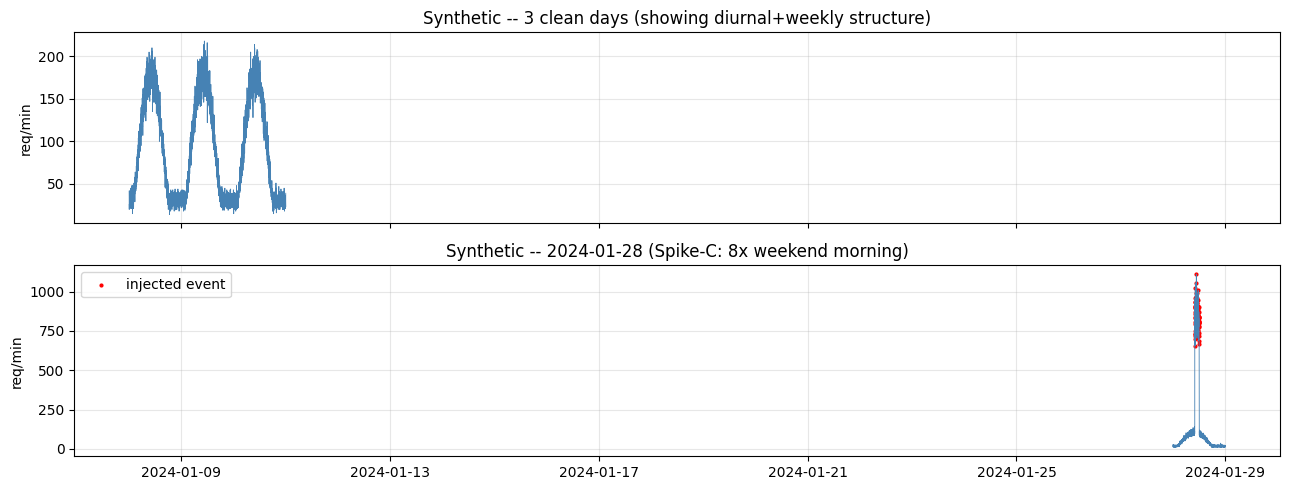

In [64]:
# Quick sanity plot: see the seasonal structure and an event.
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

slice_a = syn[(syn["timestamp"] >= "2024-01-08") & (syn["timestamp"] < "2024-01-11")]
axes[0].plot(slice_a["timestamp"], slice_a["value"], lw=0.6, color="steelblue")
axes[0].set_title("Synthetic -- 3 clean days (showing diurnal+weekly structure)")
axes[0].set_ylabel("req/min"); axes[0].grid(alpha=0.3)

slice_b = syn[(syn["timestamp"] >= "2024-01-28") & (syn["timestamp"] < "2024-01-29")]
axes[1].plot(slice_b["timestamp"], slice_b["value"], lw=0.6, color="steelblue")
event_b = slice_b[slice_b["y_true"]]
axes[1].scatter(event_b["timestamp"], event_b["value"],
                color="red", s=4, label="injected event")
axes[1].set_title("Synthetic -- 2024-01-28 (Spike-C: 8x weekend morning)")
axes[1].set_ylabel("req/min"); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()


In [65]:
v1_syn  = detector_v1(syn[["timestamp", "value"]])
v2w_syn = detector_v2(syn[["timestamp", "value"]], pooling="is_weekend")
v2d_syn = detector_v2(syn[["timestamp", "value"]], pooling="dow")

syn_eval = (syn[["timestamp", "value", "y_true"]]
            .merge(v1_syn[["timestamp", "robust_z_v1"]], on="timestamp")
            .merge(v2w_syn[["timestamp", "robust_z_v2_is_weekend"]], on="timestamp")
            .merge(v2d_syn[["timestamp", "robust_z_v2_dow"]], on="timestamp"))

syn_scored_mask = (syn_eval[["robust_z_v1", "robust_z_v2_is_weekend",
                             "robust_z_v2_dow"]].notna().all(axis=1)) & syn_test_mask

print(f"Fully-scored test minutes: {int(syn_scored_mask.sum()):,}")


Fully-scored test minutes: 56,160


In [66]:
# Calibrate on benign synthetic minutes.
syn_benign_mask = syn_scored_mask & ~syn_eval["y_true"]
print(f"Synthetic benign pool: {int(syn_benign_mask.sum()):,}")

k_v1_syn  = calibrate_k(syn_eval["robust_z_v1"],            syn_benign_mask)
k_v2w_syn = calibrate_k(syn_eval["robust_z_v2_is_weekend"], syn_benign_mask)
k_v2d_syn = calibrate_k(syn_eval["robust_z_v2_dow"],        syn_benign_mask)

print(f"Calibrated k on synthetic (target FPR = {TARGET_FPR:.1%}):")
print(f"  V1:           k = {k_v1_syn:.4f}")
print(f"  V2-weekend:   k = {k_v2w_syn:.4f}")
print(f"  V2-dow:       k = {k_v2d_syn:.4f}")

syn_results = pd.DataFrame([
    score_at_k("V1 (current)",     syn_eval["robust_z_v1"],
               syn_eval["y_true"], k_v1_syn,  syn_test_mask),
    score_at_k("V2-weekend (new)", syn_eval["robust_z_v2_is_weekend"],
               syn_eval["y_true"], k_v2w_syn, syn_test_mask),
    score_at_k("V2-dow (new)",     syn_eval["robust_z_v2_dow"],
               syn_eval["y_true"], k_v2d_syn, syn_test_mask),
])
print()
print("=== Synthetic evaluation (FPR-calibrated) ===")
syn_results


Synthetic benign pool: 55,522
Calibrated k on synthetic (target FPR = 0.5%):
  V1:           k = 2.6980
  V2-weekend:   k = 2.7943
  V2-dow:       k = 2.8687

=== Synthetic evaluation (FPR-calibrated) ===


,detector,k,precision,recall,f1,fpr,TP,FP,FN,TN,flagged,scored
0,V1 (current),2.6980,0.7125,0.9984,0.8316,0.00463,637,257,1,55265,894,56160
1,V2-weekend (new),2.7943,0.6973,1.0000,0.8216,0.00499,638,277,0,55245,915,56160
2,V2-dow (new),2.8687,0.6965,1.0000,0.8211,0.00501,638,278,0,55244,916,56160


## 6. Per-event recall on synthetic

Aggregate metric (overall recall) can hide failures on specific event
classes. This breaks down per-event whether each detector caught it
(>= 1 minute flagged inside the event window).


In [67]:
def per_event_recall(scores, k, test_mask, events_list, df_eval):
    flag = (scores > k) & test_mask & scores.notna()
    rows = []
    for name, start, end, mult in events_list:
        s = pd.Timestamp(start); e = pd.Timestamp(end)
        ev_mask = (df_eval["timestamp"] >= s) & (df_eval["timestamp"] <= e)
        n_ev    = int(ev_mask.sum())
        n_flag  = int((flag & ev_mask).sum())
        rows.append({"event": name, "multiplier": mult,
                     "event_minutes": n_ev, "flagged_minutes": n_flag,
                     "caught": n_flag > 0,
                     "minute_recall": round(n_flag / n_ev, 3) if n_ev else 0.0})
    return pd.DataFrame(rows)

print("--- V1 per-event ---")
print(per_event_recall(syn_eval["robust_z_v1"],            k_v1_syn,
                       syn_test_mask, SYNTHETIC_EVENTS, syn_eval).to_string(index=False))
print()
print("--- V2-weekend per-event ---")
print(per_event_recall(syn_eval["robust_z_v2_is_weekend"], k_v2w_syn,
                       syn_test_mask, SYNTHETIC_EVENTS, syn_eval).to_string(index=False))
print()
print("--- V2-dow per-event ---")
print(per_event_recall(syn_eval["robust_z_v2_dow"],        k_v2d_syn,
                       syn_test_mask, SYNTHETIC_EVENTS, syn_eval).to_string(index=False))


--- V1 per-event ---
         event  multiplier  event_minutes  flagged_minutes  caught  minute_recall
 Spike-A small         3.0             61               61    True          1.000
Spike-B medium         5.0             91               91    True          1.000
 Spike-C large         8.0            121              121    True          1.000
 Spike-D small         3.0             61               61    True          1.000
Spike-E medium         5.0             91               91    True          1.000
 Spike-F large         8.0            121              121    True          1.000
 Spike-G small         3.0             31               30    True          0.968
Spike-H medium         5.0             61               61    True          1.000

--- V2-weekend per-event ---
         event  multiplier  event_minutes  flagged_minutes  caught  minute_recall
 Spike-A small         3.0             61               61    True            1.0
Spike-B medium         5.0             91      

### 6.1 By-magnitude rollup -- does V2 lose sensitivity to small spikes?

Aggregating across event multipliers (3x / 5x / 8x) directly tests whether
V2's hourly aggregation smooths small spikes below the calibrated threshold.
If V2's mean minute-recall drops materially at 3x while staying flat at
5x/8x, the storage scheme is paying for its memory savings with sensitivity
to short low-magnitude bursts -- relevant for branch D of the verdict
cheat-sheet.


In [68]:
per_v1  = per_event_recall(syn_eval["robust_z_v1"],            k_v1_syn,
                           syn_test_mask, SYNTHETIC_EVENTS, syn_eval)
per_v2w = per_event_recall(syn_eval["robust_z_v2_is_weekend"], k_v2w_syn,
                           syn_test_mask, SYNTHETIC_EVENTS, syn_eval)
per_v2d = per_event_recall(syn_eval["robust_z_v2_dow"],        k_v2d_syn,
                           syn_test_mask, SYNTHETIC_EVENTS, syn_eval)

def by_magnitude(per_ev_df):
    return per_ev_df.groupby("multiplier").agg(
        n_events=("event", "count"),
        caught=("caught", "sum"),
        mean_minute_recall=("minute_recall", "mean"),
    ).round(3).reset_index()

print("--- V1 by magnitude ---")
print(by_magnitude(per_v1).to_string(index=False))
print()
print("--- V2-weekend by magnitude ---")
print(by_magnitude(per_v2w).to_string(index=False))
print()
print("--- V2-dow by magnitude ---")
print(by_magnitude(per_v2d).to_string(index=False))


--- V1 by magnitude ---
 multiplier  n_events  caught  mean_minute_recall
        3.0         3       3               0.989
        5.0         3       3               1.000
        8.0         2       2               1.000

--- V2-weekend by magnitude ---
 multiplier  n_events  caught  mean_minute_recall
        3.0         3       3                 1.0
        5.0         3       3                 1.0
        8.0         2       2                 1.0

--- V2-dow by magnitude ---
 multiplier  n_events  caught  mean_minute_recall
        3.0         3       3                 1.0
        5.0         3       3                 1.0
        8.0         2       2                 1.0


## 7. Detector agreement (Jaccard + score correlation)

How redundant is V2 with V1? If Jaccard > 0.7 and Pearson > 0.9, V2 is
essentially the same detector by another name -- the switch is purely a
storage/CPU optimization with no behavioral change. If agreement is low,
V2 is a different detector and the choice matters semantically.


In [69]:
def agreement_table(eval_df, scored_mask, kvals, label):
    flag_v1  = ((eval_df["robust_z_v1"]            > kvals["v1"])  & scored_mask)
    flag_v2w = ((eval_df["robust_z_v2_is_weekend"] > kvals["v2w"]) & scored_mask)
    flag_v2d = ((eval_df["robust_z_v2_dow"]        > kvals["v2d"]) & scored_mask)

    pearson = eval_df.loc[scored_mask,
                          ["robust_z_v1", "robust_z_v2_is_weekend",
                           "robust_z_v2_dow"]].corr().round(3)
    jacc = pd.DataFrame({
        "V1":         [1.0, jaccard(flag_v1, flag_v2w), jaccard(flag_v1, flag_v2d)],
        "V2-weekend": [jaccard(flag_v1, flag_v2w), 1.0, jaccard(flag_v2w, flag_v2d)],
        "V2-dow":     [jaccard(flag_v1, flag_v2d), jaccard(flag_v2w, flag_v2d), 1.0],
    }, index=["V1", "V2-weekend", "V2-dow"]).round(3)

    print(f"=== {label}: Pearson correlation of robust_z scores ===")
    print(pearson)
    print()
    print(f"=== {label}: Jaccard of flag sets at calibrated k ===")
    print(jacc)
    return pearson, jacc

_ = agreement_table(nasa_eval, scored_mask, ks_nasa, "NASA")
print()
_ = agreement_table(syn_eval, syn_scored_mask,
                    {"v1": k_v1_syn, "v2w": k_v2w_syn, "v2d": k_v2d_syn},
                    "Synthetic")


=== NASA: Pearson correlation of robust_z scores ===
                        robust_z_v1  robust_z_v2_is_weekend  robust_z_v2_dow
robust_z_v1                   1.000                   0.968            0.883
robust_z_v2_is_weekend        0.968                   1.000            0.900
robust_z_v2_dow               0.883                   0.900            1.000

=== NASA: Jaccard of flag sets at calibrated k ===
               V1  V2-weekend  V2-dow
V1          1.000       0.471   0.343
V2-weekend  0.471       1.000   0.454
V2-dow      0.343       0.454   1.000

=== Synthetic: Pearson correlation of robust_z scores ===
                        robust_z_v1  robust_z_v2_is_weekend  robust_z_v2_dow
robust_z_v1                   1.000                   0.996            0.993
robust_z_v2_is_weekend        0.996                   1.000            0.998
robust_z_v2_dow               0.993                   0.998            1.000

=== Synthetic: Jaccard of flag sets at calibrated k ===
           

## 8. Threshold-sweep curves

Independent of the calibrated operating point, where do the F1 curves of
V1 and V2 sit relative to each other? If V2's curve is strictly below V1's,
V2 is dominated regardless of threshold. If they cross, they are trading
sensitivity for something else.


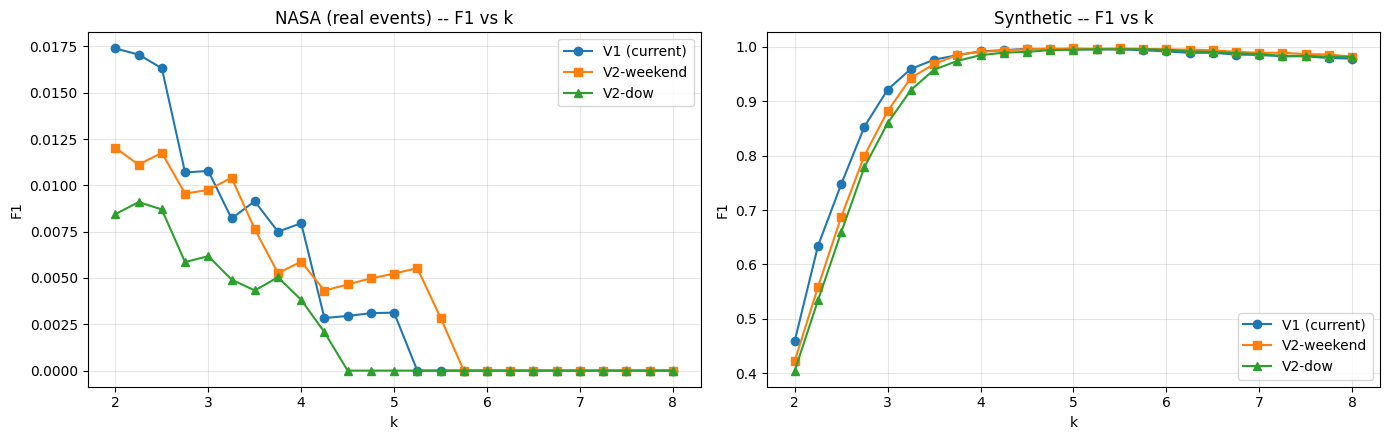

In [70]:
def sweep(scores, y_true, scored_mask, ks):
    rows = []
    mask = scored_mask & scores.notna()
    yt = y_true[mask].to_numpy()
    sc = scores[mask].to_numpy()
    for k in ks:
        yp = sc > k
        rows.append({
            "k": k,
            "precision": precision_score(yt, yp, zero_division=0),
            "recall":    recall_score(yt, yp, zero_division=0),
            "f1":        f1_score(yt, yp, zero_division=0),
            "flagged_frac": yp.mean(),
        })
    return pd.DataFrame(rows)

ks = np.arange(2.0, 8.01, 0.25)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (label, eval_df, sm, y_col) in zip(
    axes,
    [("NASA (real events)", nasa_eval, scored_mask,     "y_real"),
     ("Synthetic",          syn_eval,  syn_scored_mask, "y_true")]
):
    s_v1  = sweep(eval_df["robust_z_v1"],            eval_df[y_col], sm, ks)
    s_v2w = sweep(eval_df["robust_z_v2_is_weekend"], eval_df[y_col], sm, ks)
    s_v2d = sweep(eval_df["robust_z_v2_dow"],        eval_df[y_col], sm, ks)
    ax.plot(s_v1["k"],  s_v1["f1"],  marker="o", label="V1 (current)")
    ax.plot(s_v2w["k"], s_v2w["f1"], marker="s", label="V2-weekend")
    ax.plot(s_v2d["k"], s_v2d["f1"], marker="^", label="V2-dow")
    ax.set_title(f"{label} -- F1 vs k")
    ax.set_xlabel("k"); ax.set_ylabel("F1")
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


## 9. V2 SCALE_FLOOR sensitivity sweep

V2 protects against division-by-near-zero with `SCALE_FLOOR=1.0` (IQR floor).
V1 uses `EPS=1e-6` and no floor. That asymmetry means part of any V1/V2 gap
could be attributed to the floor rather than to the storage scheme. This
sweep checks whether the verdict is sensitive to that magic number.

Each row is FPR-calibrated independently at its own floor -- comparing F1
at a fixed FPR target keeps the comparison apples-to-apples across floors.


In [71]:
FLOORS = [0.0, 0.5, 1.0, 2.0, 4.0]

floor_rows = []
for floor in FLOORS:
    v2w = detector_v2(syn[["timestamp", "value"]], pooling="is_weekend",
                      scale_floor=floor)
    v2d = detector_v2(syn[["timestamp", "value"]], pooling="dow",
                      scale_floor=floor)
    sw = (syn[["timestamp", "y_true"]]
          .merge(v2w[["timestamp", "robust_z_v2_is_weekend"]], on="timestamp")
          .merge(v2d[["timestamp", "robust_z_v2_dow"]],        on="timestamp"))
    sm = (sw[["robust_z_v2_is_weekend", "robust_z_v2_dow"]].notna().all(axis=1)
          & syn_test_mask)
    benign = sm & ~sw["y_true"]
    k_w = calibrate_k(sw["robust_z_v2_is_weekend"], benign)
    k_d = calibrate_k(sw["robust_z_v2_dow"],        benign)
    rw = score_at_k(f"V2-weekend (floor={floor})",
                    sw["robust_z_v2_is_weekend"], sw["y_true"], k_w, syn_test_mask)
    rd = score_at_k(f"V2-dow (floor={floor})",
                    sw["robust_z_v2_dow"],        sw["y_true"], k_d, syn_test_mask)
    rw["scale_floor"] = floor
    rd["scale_floor"] = floor
    floor_rows.extend([rw, rd])

floor_df = pd.DataFrame(floor_rows)[["scale_floor", "detector", "k",
                                     "precision", "recall", "f1", "fpr",
                                     "TP", "FP", "FN"]]
v1_ref = syn_results.loc[syn_results["detector"] == "V1 (current)"].iloc[0]
print(f"Reference: V1 synthetic F1 = {v1_ref['f1']:.4f}  "
      f"(precision={v1_ref['precision']:.3f}, recall={v1_ref['recall']:.3f}, "
      f"fpr={v1_ref['fpr']:.4f})")
print()
print("=== V2 floor sweep on synthetic (FPR-calibrated at each floor) ===")
print(floor_df.to_string(index=False))


Reference: V1 synthetic F1 = 0.8316  (precision=0.713, recall=0.998, fpr=0.0046)

=== V2 floor sweep on synthetic (FPR-calibrated at each floor) ===
 scale_floor               detector      k  precision  recall     f1     fpr  TP  FP  FN
         0.0 V2-weekend (floor=0.0) 2.7943     0.6973     1.0 0.8216 0.00499 638 277   0
         0.0     V2-dow (floor=0.0) 2.8687     0.6965     1.0 0.8211 0.00501 638 278   0
         0.5 V2-weekend (floor=0.5) 2.7943     0.6973     1.0 0.8216 0.00499 638 277   0
         0.5     V2-dow (floor=0.5) 2.8687     0.6965     1.0 0.8211 0.00501 638 278   0
         1.0 V2-weekend (floor=1.0) 2.7943     0.6973     1.0 0.8216 0.00499 638 277   0
         1.0     V2-dow (floor=1.0) 2.8687     0.6965     1.0 0.8211 0.00501 638 278   0
         2.0 V2-weekend (floor=2.0) 2.7943     0.6973     1.0 0.8216 0.00499 638 277   0
         2.0     V2-dow (floor=2.0) 2.8687     0.6965     1.0 0.8211 0.00501 638 278   0
         4.0 V2-weekend (floor=4.0) 2.7943     0.6

The synthetic floor sweep above tests floor sensitivity in a regime where
hourly IQR ≫ floor everywhere (clipped diurnal mean ≥ 30 + Poisson
std ≈ 5.5  ⇒  IQR ≈ 7-8). On NASA, deep-night IQR is 0-1 -- the regime
where SCALE_FLOOR actually binds. Without an ablation in that regime, a
reviewer can ask whether the verdict generalizes from synthetic to
production-like data.

This cell mirrors section 9 on NASA. If F1 stays flat across floors here
too, the floor is genuinely defensive plumbing rather than a tuning knob,
and the V1-vs-V2 verdict is not an artifact of the floor choice.

In [72]:
# V2 SCALE_FLOOR sensitivity on NASA. Each row FPR-calibrated independently
# at its own floor -- F1 at fixed FPR is the apples-to-apples comparison.

floor_rows_nasa = []
for floor in FLOORS:
    v2w_n = detector_v2(nasa[["timestamp", "value"]], pooling="is_weekend",
                        scale_floor=floor)
    v2d_n = detector_v2(nasa[["timestamp", "value"]], pooling="dow",
                        scale_floor=floor)
    sw = (nasa[["timestamp", "y_real", "y_any"]]
          .merge(v2w_n[["timestamp", "robust_z_v2_is_weekend"]], on="timestamp")
          .merge(v2d_n[["timestamp", "robust_z_v2_dow"]],         on="timestamp"))
    sm = sw[["robust_z_v2_is_weekend", "robust_z_v2_dow"]].notna().all(axis=1)
    benign = sm & ~sw["y_any"]    # excludes both real and control events
    k_w = calibrate_k(sw["robust_z_v2_is_weekend"], benign)
    k_d = calibrate_k(sw["robust_z_v2_dow"],        benign)
    rw = score_at_k(f"V2-weekend (floor={floor})",
                    sw["robust_z_v2_is_weekend"], sw["y_real"], k_w, sm)
    rd = score_at_k(f"V2-dow (floor={floor})",
                    sw["robust_z_v2_dow"],        sw["y_real"], k_d, sm)
    rw["scale_floor"] = floor
    rd["scale_floor"] = floor
    floor_rows_nasa.extend([rw, rd])

floor_df_nasa = pd.DataFrame(floor_rows_nasa)[["scale_floor", "detector", "k",
                                                "precision", "recall", "f1", "fpr",
                                                "TP", "FP", "FN"]]
v1_ref_nasa = nasa_results.loc[nasa_results["detector"] == "V1 (current)"].iloc[0]
print(f"Reference: V1 NASA F1 = {v1_ref_nasa['f1']:.4f}  "
      f"(precision={v1_ref_nasa['precision']:.3f}, recall={v1_ref_nasa['recall']:.3f}, "
      f"fpr={v1_ref_nasa['fpr']:.4f})")
print()
print("=== V2 floor sweep on NASA (FPR-calibrated at each floor) ===")
print(floor_df_nasa.to_string(index=False))

Reference: V1 NASA F1 = 0.0084  (precision=0.011, recall=0.007, fpr=0.0051)

=== V2 floor sweep on NASA (FPR-calibrated at each floor) ===
 scale_floor               detector      k  precision  recall    f1     fpr  TP  FP  FN
         0.0 V2-weekend (floor=0.0) 4.0469     0.0076  0.0050 0.006 0.00575   3 394 598
         0.0     V2-dow (floor=0.0) 4.1836     0.0026  0.0017 0.002 0.00558   1 382 600
         0.5 V2-weekend (floor=0.5) 4.0469     0.0076  0.0050 0.006 0.00575   3 394 598
         0.5     V2-dow (floor=0.5) 4.1836     0.0026  0.0017 0.002 0.00558   1 382 600
         1.0 V2-weekend (floor=1.0) 4.0469     0.0076  0.0050 0.006 0.00575   3 394 598
         1.0     V2-dow (floor=1.0) 4.1644     0.0026  0.0017 0.002 0.00559   1 383 600
         2.0 V2-weekend (floor=2.0) 4.0469     0.0076  0.0050 0.006 0.00575   3 394 598
         2.0     V2-dow (floor=2.0) 4.1444     0.0026  0.0017 0.002 0.00559   1 383 600
         4.0 V2-weekend (floor=4.0) 4.0469     0.0075  0.0050 0.006 0

## 10. Side-by-side summary

Single combined table -- read this top-down for the verdict.


In [73]:
nasa_tagged = nasa_results.copy()
nasa_tagged["dataset"] = "NASA"
syn_tagged  = syn_results.copy()
syn_tagged["dataset"] = "Synthetic"
syn_tagged["perseid_hit"] = np.nan   # not applicable to synthetic

cols = ["dataset", "detector", "k", "precision", "recall", "f1", "fpr",
        "events_covered", "perseid_hit", "TP", "FP", "FN", "TN"]
combined = pd.concat([nasa_tagged.reindex(columns=cols),
                      syn_tagged.reindex(columns=cols)],
                     ignore_index=True)
print("=== Final comparison ===")
print(combined.to_string(index=False))


=== Final comparison ===
  dataset         detector      k  precision  recall     f1     fpr events_covered  perseid_hit  TP  FP  FN    TN
     NASA     V1 (current) 3.2881     0.0112  0.0067 0.0084 0.00514            3/3     0.008681   4 352 597 68167
     NASA V2-weekend (new) 4.0469     0.0076  0.0050 0.0060 0.00575            3/3     0.022917   3 394 598 68125
     NASA     V2-dow (new) 4.1644     0.0026  0.0017 0.0020 0.00559            1/3     0.018750   1 383 600 68136
Synthetic     V1 (current) 2.6980     0.7125  0.9984 0.8316 0.00463            NaN          NaN 637 257   1 55265
Synthetic V2-weekend (new) 2.7943     0.6973  1.0000 0.8216 0.00499            NaN          NaN 638 277   0 55245
Synthetic     V2-dow (new) 2.8687     0.6965  1.0000 0.8211 0.00501            NaN          NaN 638 278   0 55244


## 11. Verdict cheat-sheet

Read the section 10 table against this decision tree:

**A. V2-weekend matches V1 on F1 within ~3 points on synthetic AND NASA
event coverage agrees:**
Switch to V2-weekend. Same accuracy, ~30x less memory, O(1) scoring.
The storage scheme is a strict win when bucketing matches.

**B. V2-dow significantly underperforms V2-weekend on NASA but matches
on synthetic:**
Confirms the n=3 hypothesis -- NASA is too short to support DOW pooling.
In production, DOW pooling becomes safe once the buffer covers >= 6 weeks.
Recommended deploy posture: V2 storage + is_weekend pooling for the thesis
evaluation, with a config flag to switch to DOW pooling when buffer history
is long enough.

**C. V2 (either variant) drops F1 by > 5 points vs V1 on synthetic:**
Check section 6.1 (by-magnitude). If the loss is concentrated at 3x spikes,
the hourly aggregation is smoothing them out. Then check section 9 (floor
sweep) -- if F1 recovers at floor=0.0 or floor=0.5, the floor is the
suppressor and lowering it makes V2 viable. If section 9 shows F1 flat
across floors, the storage scheme itself is the cost -- keep V1.

**D. Pearson(V1, V2-weekend) > 0.9 on the underlying scores:**
V2 is capturing the same continuous signal as V1 (the conclusion
defensible against a reviewer asking "are these the same detector?").
Jaccard at calibrated k can vary widely on heavy-tailed real data
(NASA: ~0.47; synthetic: ~0.85) because thresholding is sensitive to
small denominator differences -- this is a property of any robust-z
detector, not a V1/V2 difference. The operationally relevant test is
whether V1 and V2 give matching event coverage at fixed FPR
(verdict A), not flag-level agreement at a specific threshold.


## 12. Export

In [74]:
combined.to_csv(OUT_DIR / "v1_vs_v2_summary.csv", index=False)
floor_df.to_csv(OUT_DIR / "v1_vs_v2_floor_sweep.csv", index=False)
floor_df_nasa.to_csv(OUT_DIR / "v1_vs_v2_floor_sweep_nasa.csv", index=False)

mag_v1  = by_magnitude(per_v1);  mag_v1["detector"]  = "V1"
mag_v2w = by_magnitude(per_v2w); mag_v2w["detector"] = "V2-weekend"
mag_v2d = by_magnitude(per_v2d); mag_v2d["detector"] = "V2-dow"
mag_all = pd.concat([mag_v1, mag_v2w, mag_v2d], ignore_index=True)
mag_all = mag_all[["detector", "multiplier", "n_events",
                   "caught", "mean_minute_recall"]]
mag_all.to_csv(OUT_DIR / "v1_vs_v2_by_magnitude.csv", index=False)

config = {
    "window_days":    WINDOW_DAYS,
    "target_fpr":     TARGET_FPR,
    "scale_floor_v2": SCALE_FLOOR,
    "min_samples_v1": MIN_SAMPLES_V1,
    "min_samples_v2": MIN_SAMPLES_V2,
    "floor_sweep_values": FLOORS,
    "synthetic_events": [{"name": n, "start": s, "end": e, "multiplier": m}
                         for n, s, e, m in SYNTHETIC_EVENTS],
    "nasa_real_events":    [{"name": n, "start": s, "end": e}
                            for n, s, e in NASA_REAL_EVENTS],
    "nasa_control_events": [{"name": n, "start": s, "end": e}
                            for n, s, e in NASA_CONTROL_EVENTS],
}
with open(OUT_DIR / "v1_vs_v2_config.json", "w") as f:
    json.dump(config, f, indent=2)

for p in ["v1_vs_v2_summary.csv", "v1_vs_v2_floor_sweep.csv",
          "v1_vs_v2_floor_sweep_nasa.csv",
          "v1_vs_v2_by_magnitude.csv", "v1_vs_v2_config.json"]:
    print(f"Wrote {OUT_DIR / p}")


Wrote outputs\v1_vs_v2_summary.csv
Wrote outputs\v1_vs_v2_floor_sweep.csv
Wrote outputs\v1_vs_v2_floor_sweep_nasa.csv
Wrote outputs\v1_vs_v2_by_magnitude.csv
Wrote outputs\v1_vs_v2_config.json
